In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn


In [2]:
# Loading dataset
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Provides Basic info about columns, types, and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
#Provides Summary statistics for numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Sum of null values in each column
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
# Count of unique values for categorical variables
df['Sex'].value_counts()
df['Embarked'].value_counts()
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

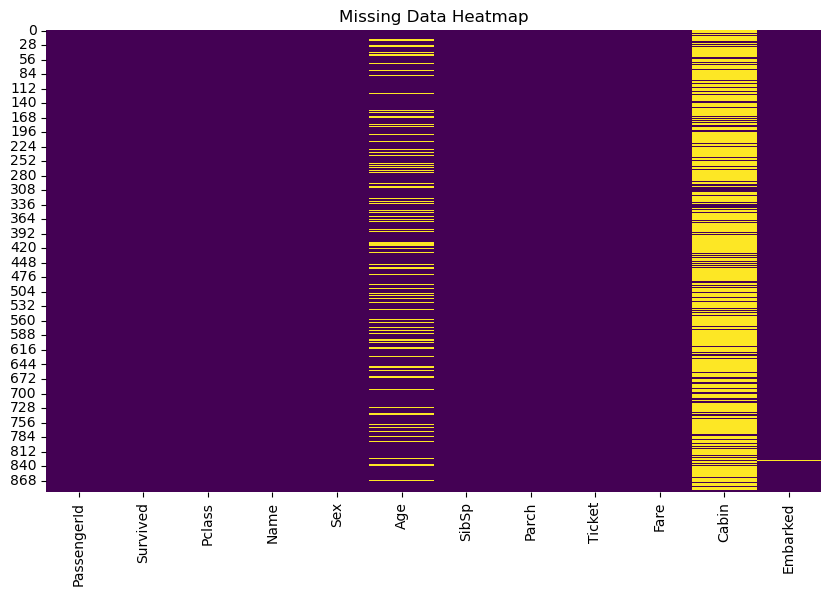

In [7]:
#Visualizing Missing Data

plt.figure(figsize=(10,6))
sbn.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

In [8]:
#Feature Engineering: Create New Features

# Creating a new feature: FamilySize
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Log transformation for Fare to handle skew
df['Fare_log'] = np.log1p(df['Fare'])


## Univariate Analysis

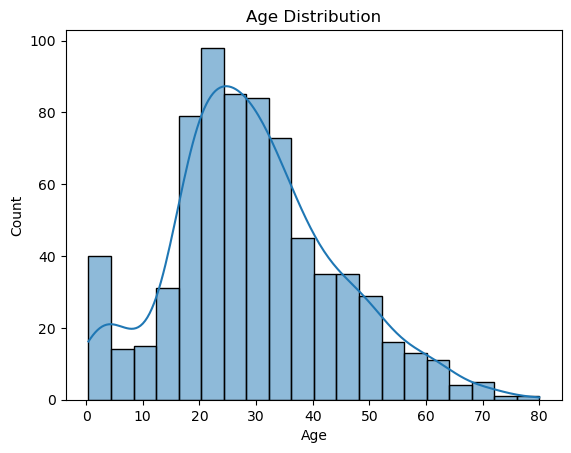

In [9]:
#Histogram to show Distribution of Age
sbn.histplot(df['Age'].dropna(), kde=True)
plt.title('Age Distribution')
plt.show()

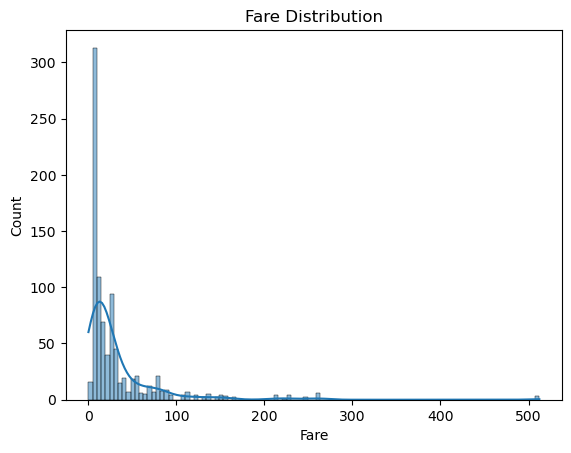

In [10]:
# Fare Distribution
sbn.histplot(df['Fare'], kde=True)
plt.title('Fare Distribution')
plt.show()

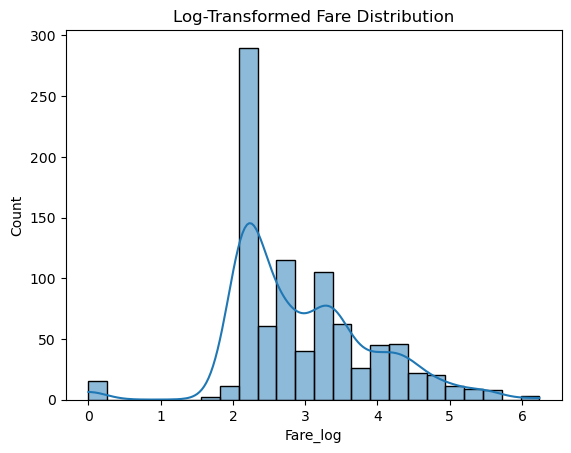

In [11]:
# Log-transformed Fare
sbn.histplot(df['Fare_log'], kde=True)
plt.title('Log-Transformed Fare Distribution')
plt.show()

## Bivariate Analysis

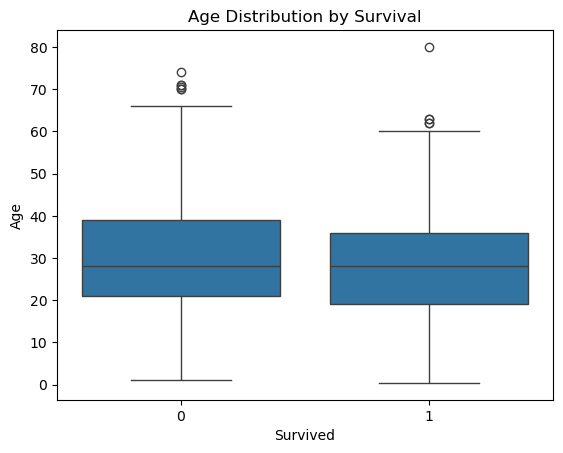

In [12]:
#Boxplot – Age vs Survived

sbn.boxplot(x='Survived', y='Age', data=df)
plt.title('Age Distribution by Survival')
plt.show()


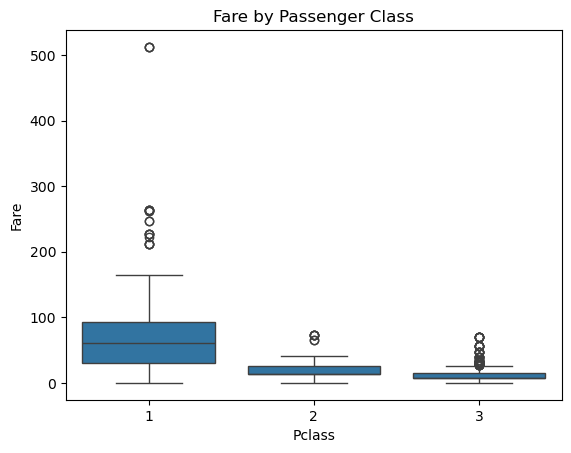

In [13]:
#Fare by Class
sbn.boxplot(x='Pclass', y='Fare', data=df)
plt.title('Fare by Passenger Class')
plt.show()

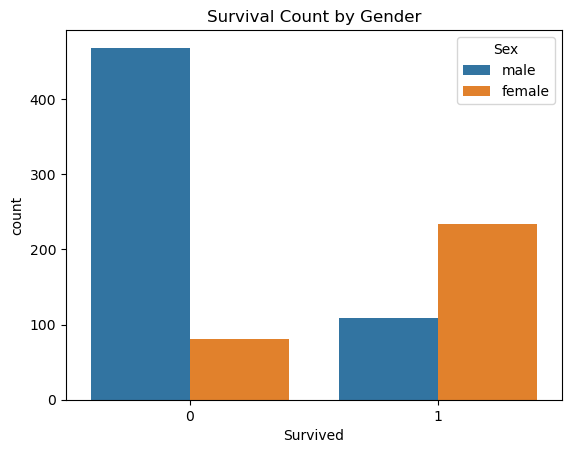

In [14]:
# Survival Count by Gender
sbn.countplot(x='Survived', hue='Sex', data=df)
plt.title('Survival Count by Gender')
plt.show()

## Heatmap – Correlation Matrix

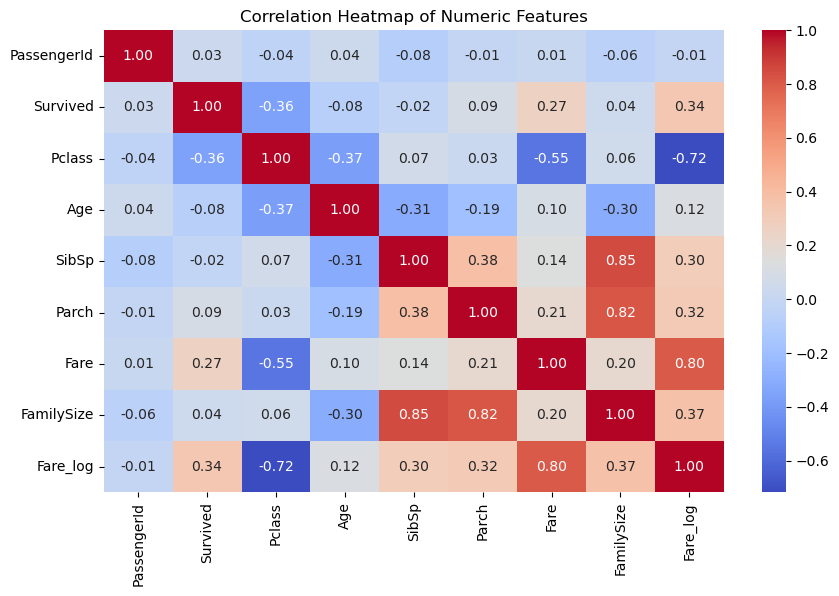

In [15]:
# Filter only numeric columns and drop missing values
numeric_df = df.select_dtypes(include=['int64', 'float64']).dropna()

# Plot heatmap
plt.figure(figsize=(10, 6))
sbn.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


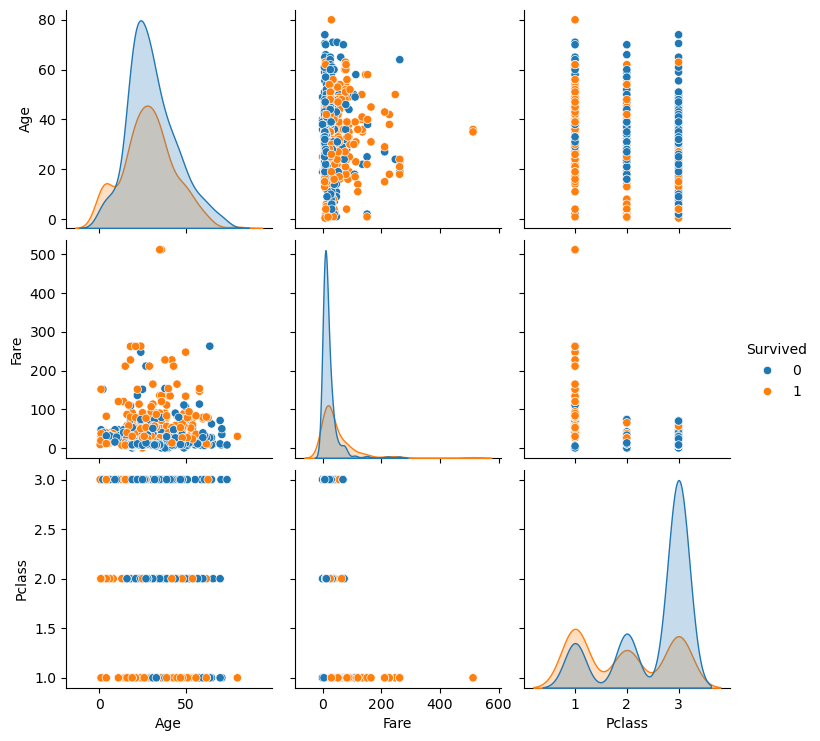

In [16]:
#Pairplot – Visualize relationships

sbn.pairplot(df[['Survived', 'Age', 'Fare', 'Pclass']], hue='Survived')
plt.show()

In [17]:
# Grouped Survival Rates

print("Survival Rate by Class:\n", df.groupby('Pclass')['Survived'].mean())
print("Survival Rate by Sex:\n", df.groupby('Sex')['Survived'].mean())
print("Survival Rate by Embarked:\n", df.groupby('Embarked')['Survived'].mean())
print("Survival Rate by Family Size:\n", df.groupby('FamilySize')['Survived'].mean())

Survival Rate by Class:
 Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Survival Rate by Sex:
 Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Survival Rate by Embarked:
 Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64
Survival Rate by Family Size:
 FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64
